Code to load in the merged_metadata Excel file and filter for relevent metadata columns that could be used to predict water quality.

Initially, an MLP (Mylti-Layer Perceptron) is trained and evaluated using a feature vector. 

An XGBoost (Extreme Gradient Boosting) model is also trained and evaluated for a comparison. However, the MLP is expected to perform better as MLPs typically perform better with complex feature learning whilst EGBoost is better with structured data, and its performance depends heavily on the dataset.

These models both use 2 classes of water quality as targets. The poor/moderate classes are combined (0), whilst the good class remains seperate (2).

In [1]:
#Imports

#Basic
import numpy as np
from pathlib import Path
import pandas as pd
from glob import glob
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import os

#scikit-learn
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

#For the model
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import shap

2026-01-14 12:07:50.154827: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-14 12:07:50.433211: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-14 12:07:51.922991: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/tqdm/auto.py:21: 

In [2]:
#Loading the csv

#Setting the path
REPO_NAME = "earthwatch-cnn"
BASE_DIR = next(
    p for p in Path.cwd().parents
    if p.name == REPO_NAME)
DATA_DIR = BASE_DIR / "data"

#Loading the data
merged_df = pd.read_excel(DATA_DIR / "merged_metadata.xlsx")


In [3]:
#Displaying the merged df
merged_df

,downloaded_utc,layer_title,layer_id,feature_object_id,feature_global_id,geometry_x,geometry_y,attachment_id,attachment_global_id,attachment_name,...,feedback_score,County,RBD_NAME,MNCAT_NAME,Nitrate (mg/L) MID,Phosphate (mg/L) MID,Photo URL,x,y,image_path
0,2025-11-26T17:48:11Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,12,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,-4.011572,52.434782,6,120e143f-b55e-4c10-aced-8b8f36ab4561,photo-20240525-180858.jpg,...,1,Dyfed,Western Wales,Teifi and North Ceredigion,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-4.011572,52.434782,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
1,2025-11-26T17:48:17Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,13,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,-1.997459,53.932339,7,01b85181-5e16-4bce-8ec1-864890e0eee6,photo-20240526-115416.jpg,...,2,North Yorkshire,Humber,Aire and Calder,1.50,0.075,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.997459,53.932339,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
2,2025-11-26T17:48:23Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,15,9ab3ef19-b92e-495d-8330-e5cab4f52139,-0.490153,51.398517,8,93b0b358-2840-496f-9c50-beb08e550091,photo-20240531-072047.jpg,...,3,Surrey,Thames,Maidenhead and Sunbury,7.50,0.150,https://services3.arcgis.com/SQtySBftABENTpkx/...,-0.490153,51.398517,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
3,2025-11-26T17:48:29Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,16,7065d44e-868d-41a8-bc29-3e380d44a284,-1.705773,53.341469,9,967fdeb6-6016-43ed-954a-e2778dd0fe31,photo-20240531-184342.jpg,...,1,Derbyshire,Humber,Derwent Derbyshire,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.705773,53.341469,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
4,2025-11-26T17:48:35Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,17,ece94aea-b3a2-4c72-a1b0-66b329185eb8,-1.633728,53.797123,10,e895f878-0577-40ae-9a49-ecd991ffcf85,photo-20240601-110123.jpg,...,3,West Yorkshire,Humber,Aire and Calder,3.50,0.035,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.633728,53.797123,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8999,2025-11-27T14:03:26Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11545,7479327a-dda2-4647-8e19-176fc7b7c208,-1.776789,53.921762,9974,a538e4f9-dda1-437e-8f73-952f969aa748,IMG_20251108_151702379_HDR.jpg,...,3,West Yorkshire,Humber,Wharfe and Ouse Lower,10.00,1.000,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.776789,53.921762,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9000,2025-11-27T14:03:36Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11546,9ca17c49-6a38-405f-8369-caebcbb4c445,-1.682858,53.910390,9975,d6c0b93c-614f-40f8-8129-362d9b85f4b7,IMG_20251112_123816085_HDR.jpg,...,1,West Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.682858,53.910390,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9001,2025-11-27T14:03:47Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11547,f077fd29-55c0-484c-8b03-aa1d54844b54,-1.659827,53.913112,9976,1869abcf-7f8f-4a66-86ea-c1a2b0faaef3,IMG_20251112_130858731_HDR.jpg,...,1,North Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.659827,53.913112,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...
9002,2025-11-27T14:03:57Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11548,8279d341-cfc1-4852-8b19-a58dc6eee304,-1.625267,53.904750,9977,4af7180e-6b14-4fce-8190-948063dbb8d2,IMG_20251122_091305231_HDR.jpg,...,2,North Yorkshire,Humber,Wharfe and Ouse Lower,1.50,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.625267,53.904750,C:/Users/Grace/Desktop/Earthwatch\Great_UK_Wat...


In [4]:
#Select only the columns we want
#Not selecting any empty columns
filtered_df=merged_df[["feature_global_id", "feedback_score","Freshwater body type","What is the main land use within 50m?","You selected other, what is the main land use?", 
                       "What is the main bank vegetation? (select all that apply)","You selected other, what is the main bank vegetation?","Vegetation cover in/on the water (%)",
                       "Is there any of the following on the water surface?", "Estimate the water colour","You selected other, enter the colour"]]
filtered_df
#feedback score - 1-poor, 3-good -changes to 0...2

,feature_global_id,feedback_score,Freshwater body type,What is the main land use within 50m?,"You selected other, what is the main land use?",What is the main bank vegetation? (select all that apply),"You selected other, what is the main bank vegetation?",Vegetation cover in/on the water (%),Is there any of the following on the water surface?,Estimate the water colour,"You selected other, enter the colour"
0,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,1,River,Forest,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
1,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,2,Stream,Rural_residential,NaN,"Grass_small_plants,Trees_shrubs",NaN,NaN,NaN,Colourless,NaN
2,9ab3ef19-b92e-495d-8330-e5cab4f52139,3,River,Urban_green_space,NaN,Trees_shrubs,NaN,NaN,NaN,Colourless,NaN
3,7065d44e-868d-41a8-bc29-3e380d44a284,1,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
4,ece94aea-b3a2-4c72-a1b0-66b329185eb8,3,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Concrete_imper...",NaN,NaN,NaN,Colourless,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8999,7479327a-dda2-4647-8e19-176fc7b7c208,3,River,Grassland_shrub,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9000,9ca17c49-6a38-405f-8369-caebcbb4c445,1,River,Urban_green_space,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,Foam,Brown,NaN
9001,f077fd29-55c0-484c-8b03-aa1d54844b54,1,River,Arable_agricultural,NaN,"Trees_shrubs,Grass_small_plants",NaN,NaN,Foam,Brown,NaN
9002,8279d341-cfc1-4852-8b19-a58dc6eee304,2,River,Livestock,NaN,"Trees_shrubs,Grass_small_plants,Bare_soil",NaN,NaN,NaN,Colourless,NaN


In [6]:
#Dataframe pre-processing for ML training 
#Need to change the data from categories to numerical values and normalise. 

#Splitting the columns into different data types
multilabel_col = "What is the main bank vegetation? (select all that apply)"
nominal_cols = [
    "Freshwater body type",
    "What is the main land use within 50m?",
    "Is there any of the following on the water surface?",
    "Estimate the water colour"
]
numeric_cols = ["Vegetation cover in/on the water (%)"]
TARGET = "feedback_score"

filtered_df = filtered_df.copy()

def normalize_multilabel(x):
    #Explicit handling for list/array-like types (do this first)
    if isinstance(x, (list, tuple, set, np.ndarray)):
        #Convert to plain python list of stripped strings
        out = []
        for v in x:
            if v is None:
                continue
            s = str(v).strip()
            if s and s.lower() not in ("nan", "none"):
                out.append(s)
        return out

    #Can now use pd.isna
    if pd.isna(x):
        return []

    #Split strings/scalars on the comma
    s = str(x).strip()
    if s == "" or s.lower() in ("nan", "none"):
        return []
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return parts

#Apply normalisation
filtered_df.loc[:, multilabel_col] = filtered_df[multilabel_col].apply(normalize_multilabel)

# build bank_veg_df using MultiLabelBinarizer
mlb = MultiLabelBinarizer()
bank_veg_encoded = mlb.fit_transform(filtered_df[multilabel_col])
bank_veg_df = pd.DataFrame(
    bank_veg_encoded,
    index=filtered_df.index,
    columns=[f"bankveg_{c}" for c in mlb.classes_]
)
print("bank_veg_df.shape:", bank_veg_df.shape)
print("bankveg classes (sample):", mlb.classes_[:20])

# Ensure nominal columns are strings (no lists)
def to_str_val(v):
    if isinstance(v, (list, tuple, set, np.ndarray)):
        return "|".join([str(x).strip() for x in v if x is not None and str(x).strip().lower() not in ("nan","none")])
    if pd.isna(v):
        return ""
    return str(v).strip()

for c in nominal_cols:
    filtered_df.loc[:, c] = filtered_df[c].apply(to_str_val)

#Numeric fill
filtered_df.loc[:, numeric_cols] = filtered_df[numeric_cols].astype(float).fillna(0.0)

#ColumnTransformer (exclude multi-label col)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop"
)

X_base_arr = preprocessor.fit_transform(filtered_df)

#Check if X_base_arr is sparse and make dense
try:
    from scipy import sparse
    if sparse.issparse(X_base_arr):
        X_base_arr = X_base_arr.toarray()
except Exception:
    pass

#Column names
try:
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(nominal_cols)
    base_cols = list(numeric_cols) + list(cat_names)
except Exception:
    base_cols = [f"base_{i}" for i in range(X_base_arr.shape[1])]

X_base_df = pd.DataFrame(X_base_arr, index=filtered_df.index, columns=base_cols[:X_base_arr.shape[1]])
bank_veg_df = bank_veg_df.reindex(filtered_df.index).fillna(0).astype(int)
X_df = pd.concat([X_base_df, bank_veg_df], axis=1)
X = X_df.values

y = filtered_df[TARGET].astype(int).values - 1  
#Collapse to binary classes: 1 = good, 0 = not-good (poor + moderate)
y_bin = (y == 2).astype(int)

print("Original class counts:", np.bincount(y))
print("Collapsed class counts:", np.bincount(y_bin))

print("Final X shape:", X.shape)
print("Final y shape:", y_bin.shape)

bank_veg_df.shape: (9004, 5)
bankveg classes (sample): ['Bare_soil' 'Concrete_impermeable_surface' 'Grass_small_plants' 'Other'
 'Trees_shrubs']
Original class counts: [3259 1872 3873]
Collapsed class counts: [5131 3873]
Final X shape: (9004, 64)
Final y shape: (9004,)


In [7]:
#Checking shapes of X, y, and classes
print("X shape:", X.shape)   # (n_samples, n_features)
print("y shape:", y_bin.shape)   # (n_samples,)
print("y classes:", np.unique(y_bin))

X shape: (9004, 64)
y shape: (9004,)
y classes: [0 1]


In [8]:
#Divide the data into training, validation and testing. 

#Split test off from training+validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_bin, test_size=0.10, random_state=42, stratify=y_bin)

#Split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)
#Final 80/10/10 split

print(X_train.shape, X_val.shape, X_test.shape)


(7202, 64) (901, 64) (901, 64)


In [9]:
def show_class_distribution(y, name):
    counts = np.bincount(y)
    total = len(y)
    print(f"\n{name} set:")
    for cls, cnt in enumerate(counts):
        pct = 100 * cnt / total
        label = "poor" if cls == 0 else "moderate+good"
        print(f"  {label:<15}: {cnt:4d} ({pct:5.1f}%)")

show_class_distribution(y_train, "Training")
show_class_distribution(y_val, "Validation")
show_class_distribution(y_test, "Test")


Training set:
  poor           : 4105 ( 57.0%)
  moderate+good  : 3097 ( 43.0%)

Validation set:
  poor           :  513 ( 56.9%)
  moderate+good  :  388 ( 43.1%)

Test set:
  poor           :  513 ( 56.9%)
  moderate+good  :  388 ( 43.1%)


In [10]:
#MPL model
#Training

#Setting parameters and loading training data
num_classes = len(np.unique(y_bin))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

#Cap extreme weights
for k in class_weight:
    class_weight[k] = min(class_weight[k], 3.0)

model = tf.keras.Sequential([
    layers.Input(shape=(X.shape[1],)),

    layers.Dense(512, kernel_regularizer=regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.35),

    layers.Dense(256, kernel_regularizer=regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.25),

    layers.Dense(128, kernel_regularizer=regularizers.l2(5e-5)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.15),

    layers.Dense(num_classes, activation='softmax')
])

opt = optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-5
)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Early stopping to prevent overfitting
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

#Storing the model history
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[es,rlr]
)

#Evaluating the model on the test set
y_test_cat = to_categorical(y_test, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test accuracy:", test_acc)

#Detailed classification metrics on validation set
y_val_proba = model.predict(X_val)
y_val_pred = np.argmax(y_val_proba, axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)

#Compute metrics
print("\nValidation accuracy:", accuracy_score(y_val_true, y_val_pred))
print("\nClassification report (val):")
print(classification_report(y_val_true, y_val_pred, digits=4))

print("\nConfusion matrix (val):")
print(confusion_matrix(y_val_true, y_val_pred))


Epoch 1/30


2026-01-14 12:08:09.361447: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5290 - loss: 0.8212 - val_accuracy: 0.4340 - val_loss: 0.7406 - learning_rate: 3.0000e-04
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5548 - loss: 0.7561 - val_accuracy: 0.4850 - val_loss: 0.7289 - learning_rate: 3.0000e-04
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5751 - loss: 0.7391 - val_accuracy: 0.5272 - val_loss: 0.7140 - learning_rate: 3.0000e-04
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5728 - loss: 0.7321 - val_accuracy: 0.5849 - val_loss: 0.7000 - learning_rate: 3.0000e-04
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5619 - loss: 0.7351 - val_accuracy: 0.5805 - val_loss: 0.7042 - learning_rate: 3.0000e-04
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5764 - loss: 0.7166 - val_accuracy: 0.6071 - val_loss: 0.6987 - learning_rate: 3.0000e-04
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5790 - lo

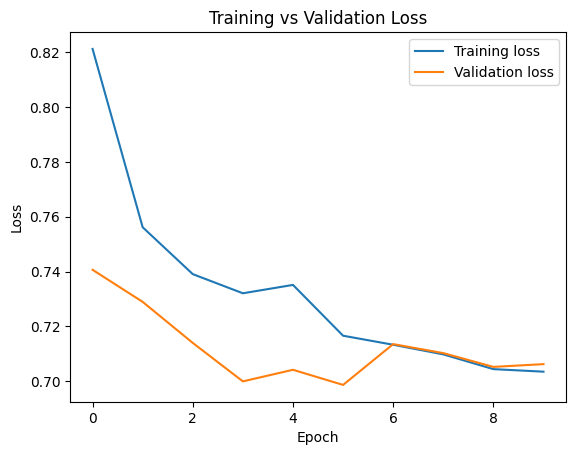

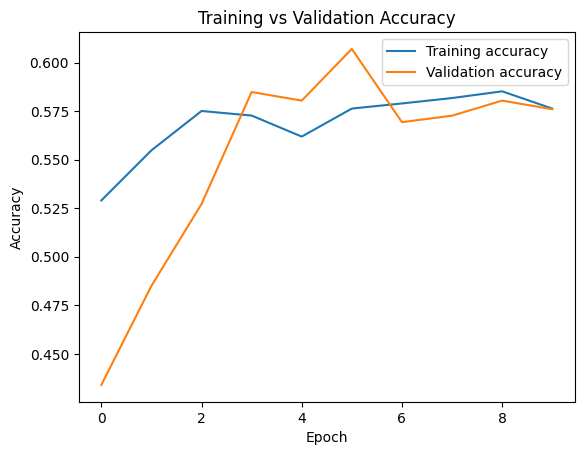

In [11]:
#Inspection-loss curves
plt.figure()
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# ACCURACY
plt.figure()
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


In [12]:
#SHAP values

# SETTINGS
n_background = 200
n_viz_samples = 500
top_k_features = 30
random_state = 42
out_dir = "shap_plots_binary"
os.makedirs(out_dir, exist_ok=True)

np.random.seed(random_state)

# ---- feature names (try to use dataframe columns if available) ----
try:
    feat_names = list(X_df.columns)
except Exception:
    feat_names = [f"f{i}" for i in range(X.shape[1])]

n_features = len(feat_names)

# ---- background + small validation subset ----
X_train_arr = np.asarray(X_train)
X_val_arr   = np.asarray(X_val)

bg_idx = np.random.choice(len(X_train_arr), size=min(n_background, len(X_train_arr)), replace=False)
background = X_train_arr[bg_idx]

val_idx = np.random.choice(len(X_val_arr), size=min(n_viz_samples, len(X_val_arr)), replace=False)
X_val_small = X_val_arr[val_idx]

n_samples = X_val_small.shape[0]

# ---- try GradientExplainer / DeepExplainer / KernelExplainer fallbacks ----
explainer = None
shap_values = None

try:
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(X_val_small)
    print("Used GradientExplainer")
except Exception as e:
    print("GradientExplainer failed:", e)
    try:
        explainer = shap.DeepExplainer(model, background)
        shap_values = explainer.shap_values(X_val_small)
        print("Used DeepExplainer")
    except Exception as e2:
        print("DeepExplainer failed:", e2)
        def f(Xi):
            Xi = np.asarray(Xi, dtype=np.float32)
            return model.predict(Xi)
        explainer = shap.KernelExplainer(f, background[:min(100, len(background))])
        shap_values = explainer.shap_values(X_val_small, nsamples=200)
        print("Used KernelExplainer (slow)")

# ---- normalise shap_values into list of 2D arrays, one per class ----
num_classes = 2
class_labels = np.unique(y_train) if 'y_train' in globals() else np.arange(num_classes)

def split_3d_array(arr3d):
    arr = np.asarray(arr3d)
    if arr.shape == (n_samples, num_classes, n_features):
        return [arr[:, c, :] for c in range(num_classes)]
    if arr.shape == (n_samples, n_features, num_classes):
        arr2 = arr.transpose(2, 0, 1)
        return [arr2[c] for c in range(num_classes)]
    if arr.shape == (num_classes, n_samples, n_features):
        return [arr[c] for c in range(num_classes)]
    if arr.shape == (n_features, n_samples, num_classes):
        arr2 = arr.transpose(2, 1, 0)
        return [arr2[c] for c in range(num_classes)]
    raise ValueError(f"Unhandled 3D shap array shape: {arr.shape}")

# Coerce into shap_per_class: list of length num_classes with shape (n_samples, n_features)
shap_per_class = None
if isinstance(shap_values, list):
    if len(shap_values) == num_classes and all(np.asarray(a).ndim == 2 for a in shap_values):
        shap_per_class = [np.asarray(a) for a in shap_values]
    elif len(shap_values) == 1:
        arr0 = np.asarray(shap_values[0])
        if arr0.ndim == 3:
            shap_per_class = split_3d_array(arr0)
        elif arr0.ndim == 2 and num_classes == 1:
            shap_per_class = [arr0]
        else:
            raise ValueError(f"Unhandled single-element list shap_values shape: {arr0.shape}")
    else:
        # try to flatten/split any 3D members and collect 2D arrays
        temp = []
        for el in shap_values:
            a = np.asarray(el)
            if a.ndim == 2:
                temp.append(a)
            elif a.ndim == 3:
                temp.extend(split_3d_array(a))
            else:
                raise ValueError(f"Unhandled element shape in shap_values list: {a.shape}")
        if len(temp) == num_classes:
            shap_per_class = temp
        else:
            raise ValueError(f"After coercion, got {len(temp)} arrays but expected {num_classes}")
else:
    arr = np.asarray(shap_values)
    if arr.ndim == 3:
        shap_per_class = split_3d_array(arr)
    elif arr.ndim == 2 and num_classes == 1:
        shap_per_class = [arr]
    else:
        raise ValueError(f"Unhandled shap_values ndarray shape: {arr.shape}")

# Final sanity check
shap_per_class = [np.asarray(a) for a in shap_per_class]
for i, a in enumerate(shap_per_class):
    if a.shape != (n_samples, n_features):
        raise ValueError(f"Class {i} shape mismatch: {a.shape} != {(n_samples, n_features)}")

print("shap_per_class shapes:", [a.shape for a in shap_per_class])

# ---- plotting loop (binary classes) ----
for c in range(num_classes):
    class_name = str(class_labels[c])
    print(f"Plotting class {c} ({class_name})")

    # Beeswarm summary
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_per_class[c], X_val_small, feature_names=feat_names, show=False)
    # increase left margin to avoid label cropping
    plt.gcf().subplots_adjust(left=0.35)
    plt.title(f"SHAP summary (beeswarm) - class {class_name}", pad=12)
    fname = os.path.join(out_dir, f"shap_beeswarm_class_{class_name}.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print("Saved:", fname)

    # Mean |SHAP| bar plot
    sh_vals_c = np.asarray(shap_per_class[c])
    mean_abs_shap = np.mean(np.abs(sh_vals_c), axis=0).ravel()

    feat_names_arr = np.asarray(feat_names)
    if feat_names_arr.shape[0] != mean_abs_shap.shape[0]:
        raise ValueError("Feature count mismatch between names and SHAP values")

    idx_sorted = np.argsort(mean_abs_shap)[::-1]
    k = min(top_k_features, mean_abs_shap.shape[0])
    top_idx = idx_sorted[:k].astype(int)
    top_feats = feat_names_arr[top_idx].tolist()
    top_vals = mean_abs_shap[top_idx]

    plt.figure(figsize=(12, max(6, 0.25 * len(top_feats))))
    y_pos = np.arange(len(top_feats))[::-1]
    plt.barh(y_pos, top_vals[::-1])
    plt.yticks(y_pos, top_feats[::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"Top {len(top_feats)} features by mean |SHAP| - class {class_name}")
    plt.gcf().subplots_adjust(left=0.35)
    fname = os.path.join(out_dir, f"shap_meanabs_bar_class_{class_name}.png")
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print("Saved:", fname)

    # Per-sample top contributions (representative sample near median magnitude)
    sample_mags = np.sum(np.abs(shap_per_class[c]), axis=1)
    median_idx = np.argsort(np.abs(sample_mags - np.median(sample_mags)))[0]
    sample_idx_global = val_idx[median_idx]
    sample_shap = shap_per_class[c][median_idx]

    topk = min(15, n_features)
    topk_idx = np.argsort(np.abs(sample_shap))[::-1][:topk]
    contrib_feats = [feat_names[i] for i in topk_idx]
    contrib_vals = sample_shap[topk_idx]

    plt.figure(figsize=(10, 5))
    colors = ['green' if v > 0 else 'red' for v in contrib_vals]
    plt.barh(np.arange(len(contrib_feats))[::-1], contrib_vals[::-1], color=colors[::-1])
    plt.yticks(np.arange(len(contrib_feats))[::-1], contrib_feats[::-1])
    plt.xlabel("SHAP value (positive -> supports prediction for this class)")
    title = f"Top {topk} feature contributions (sample idx in X_val: {sample_idx_global}) - class {class_name}"
    if hasattr(explainer, "expected_value"):
        try:
            ev = explainer.expected_value
            # expected_value may be array-like or list
            if isinstance(ev, (list, tuple, np.ndarray)):
                ev_val = ev[c] if len(ev) > c else None
            else:
                ev_val = float(ev)
            if ev_val is not None:
                title += f"\n(expected value: {float(np.round(ev_val,4))})"
        except Exception:
            pass
    plt.title(title)
    plt.gcf().subplots_adjust(left=0.35)
    fname = os.path.join(out_dir, f"shap_topcontrib_sample_class_{class_name}.png")
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close()
    print("Saved:", fname)

print("\nAll SHAP plots saved in:", out_dir)
# ------------------------------------------------------------------------



/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(500, 64))']
  warnings.warn(msg)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 64))']
  warnings.warn(msg)


Used GradientExplainer
shap_per_class shapes: [(500, 64), (500, 64)]
Plotting class 0 (0)


/tmp/ipykernel_181132/672129520.py:126: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_class[c], X_val_small, feature_names=feat_names, show=False)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: shap_plots_binary/shap_beeswarm_class_0.png
Saved: shap_plots_binary/shap_meanabs_bar_class_0.png
Saved: shap_plots_binary/shap_topcontrib_sample_class_0.png
Plotting class 1 (1)


/tmp/ipykernel_181132/672129520.py:126: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_class[c], X_val_small, feature_names=feat_names, show=False)
/home/teaching/earthwatch-cnn/earthwatch-cnn/lib/python3.10/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: shap_plots_binary/shap_beeswarm_class_1.png
Saved: shap_plots_binary/shap_meanabs_bar_class_1.png
Saved: shap_plots_binary/shap_topcontrib_sample_class_1.png

All SHAP plots saved in: shap_plots_binary


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42
)

xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict class labels
y_val_pred = xgb.predict(X_val)

# If you want probabilities:
y_val_proba = xgb.predict_proba(X_val)


              precision    recall  f1-score   support

           0     0.6443    0.5789    0.6099       513
           1     0.5091    0.5773    0.5411       388

    accuracy                         0.5782       901
   macro avg     0.5767    0.5781    0.5755       901
weighted avg     0.5860    0.5782    0.5802       901



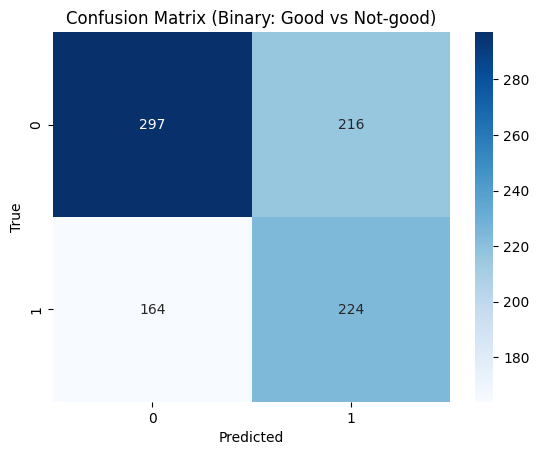

In [ ]:
print(classification_report(y_val, y_val_pred, digits=4))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Binary: Good vs Not-good)")
plt.show()


In [ ]:
# majority-class baseline
majority_acc = (y_val == np.bincount(y_train).argmax()).mean()
print("Majority class baseline accuracy:", majority_acc)

Majority class baseline accuracy: 0.5693673695893452


In [ ]:
importances = xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_df.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(20))


What is the main land use within 50m?_Arable_agricultural                    0.052293
Estimate the water colour_Colourless                                         0.036793
Freshwater body type_Ditch                                                   0.036448
What is the main land use within 50m?_Industrial_commercial                  0.034013
Freshwater body type_Pond                                                    0.032764
Is there any of the following on the water surface?_Oily_sheen,None          0.030768
Is there any of the following on the water surface?_Floating_algae,Slurry    0.030606
What is the main land use within 50m?_                                       0.029811
Estimate the water colour_Green                                              0.026191
Is there any of the following on the water surface?_                         0.025749
Freshwater body type_Other                                                   0.024259
What is the main land use within 50m?_Livestock       

In [ ]:
#Shap Values
import shap, numpy as np, pandas as pd, matplotlib.pyplot as plt
from xgboost import Booster

# ---- User variables: update if your names differ ----
xgb_model = xgb            # your trained XGBClassifier instance
X_df_all = X_df            # DataFrame of training features (same column order)
X_explain_df = pd.DataFrame(X_val, columns=X_df_all.columns)  # DataFrame for explanation
X_explain_df = X_explain_df.iloc[:1000]   # explain up to 500 rows (reduce for speed)

feature_names = X_df_all.columns.tolist()
print("Using feature count:", len(feature_names))

# ---- Try TreeExplainer on wrapper -> booster -> shap.Explainer fallback ----
explainer = None
tried = []
# 1) Try TreeExplainer on sklearn wrapper (may fail on some versions)
try:
    tried.append("TreeExplainer(sk_wrapper, model_output='probability')")
    explainer = shap.TreeExplainer(xgb_model, model_output="probability")
    print("Using TreeExplainer(xgb wrapper) with model_output='probability'")
except Exception as e1:
    print("TreeExplainer(xgb wrapper) failed:", e1)

# 2) Try TreeExplainer on raw Booster
if explainer is None:
    try:
        tried.append("TreeExplainer(xgb_model.get_booster())")
        booster = xgb_model.get_booster() if hasattr(xgb_model, "get_booster") else xgb_model
        explainer = shap.TreeExplainer(booster)   # no model_output here to be safe
        print("Using TreeExplainer on raw Booster")
    except Exception as e2:
        print("TreeExplainer(raw booster) failed:", e2)

# 3) Try high-level shap.Explainer (auto-detect)
if explainer is None:
    try:
        tried.append("shap.Explainer(xgb_model, X_explain_df)")
        explainer = shap.Explainer(xgb_model, X_explain_df)  # auto mode
        print("Using shap.Explainer (auto-detect)")
    except Exception as e3:
        print("shap.Explainer failed:", e3)

# 4) Last resort: KernelExplainer (very slow)
if explainer is None:
    print("Falling back to KernelExplainer (very slow). This may take a long time.")
    tried.append("KernelExplainer")
    bg = X_explain_df.sample(n=min(50, len(X_explain_df)), random_state=1).values
    f = lambda x: xgb_model.predict_proba(pd.DataFrame(x, columns=feature_names))[:,1]
    explainer = shap.KernelExplainer(f, bg)

print("Explainer chosen (attempts):", tried)

# ---- compute SHAP values ----
shap_values = explainer.shap_values(X_explain_df)
shap_arr = np.array(shap_values)
print("raw shap shape:", shap_arr.shape)

# If shap_arr has shape (n_samples, n_features, 1) or (1, n_samples, n_features), normalize to 2D:
def _normalize_shap(arr):
    a = np.array(arr)
    if a.ndim == 3 and a.shape[-1] == 1:
        return a.reshape(a.shape[0], a.shape[1])
    if a.ndim == 3 and a.shape[0] == 1:
        return a[0]
    if a.ndim == 2:
        return a
    raise ValueError(f"Cannot normalize SHAP array of shape {a.shape}")

shap_arr = _normalize_shap(shap_arr)
print("normalized shap_arr.shape:", shap_arr.shape)

# ---- plots ----
plt.figure(figsize=(10,7))
shap.summary_plot(shap_arr, X_explain_df, feature_names=feature_names, show=True)

plt.figure(figsize=(8,6))
shap.summary_plot(shap_arr, X_explain_df, feature_names=feature_names, plot_type="bar", show=True)

# Top features table
mean_abs = np.abs(shap_arr).mean(axis=0)
feat_imp = pd.Series(mean_abs, index=feature_names).sort_values(ascending=False)
print("Top 20 features by mean |SHAP|:\n", feat_imp.head(20))

# dependence plot for top feature
top_feat = feat_imp.index[0]
plt.figure(figsize=(8,5))
shap.dependence_plot(top_feat, shap_arr, X_explain_df, feature_names=feature_names, show=True)

# waterfall for a single instance (index 0)
i = 0
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)) and np.array(base_value).size > 1:
    base_val = np.array(base_value).ravel()[0]
else:
    base_val = base_value
shap.plots.waterfall(shap.Explanation(values=shap_arr[i],
                                     base_values=base_val,
                                     data=X_explain_df.iloc[i].values,
                                     feature_names=feature_names))


Using feature count: 64
TreeExplainer(xgb wrapper) failed: could not convert string to float: '[5E-1]'
TreeExplainer(raw booster) failed: could not convert string to float: '[5E-1]'
shap.Explainer failed: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None,

 13%|█▎        | 113/901 [00:24<02:52,  4.56it/s]


KeyboardInterrupt: 